In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import random

In [2]:
def pareto_frontier(points):
    """
    points: array-like of shape (n_points, 2)
            Minimization on both dimensions
    returns: Pareto-optimal points
    """
    points = np.asarray(points)

    # Sort by first objective (x), ascending
    sorted_idx = np.argsort(points[:, 0])
    points = points[sorted_idx]

    pareto = []
    best_y = np.inf

    for x, y in points:
        if y < best_y:
            pareto.append([x, y])
            best_y = y

    return np.array(pareto)

def clip(x, lower = 0, upper = 1.0):
    return max(lower, min(x, upper))

In [19]:
class Model:
    def __init__(self, name, error_rate, mean_energy_cost):
        self.name = name
        self.error_rate = error_rate
        self.hit_rate = 1 - error_rate
        self.mean_energy_cost = mean_energy_cost

    def inference(self, task_difficulty, energy_var = 1):
        chance = self.hit_rate*task_difficulty
        chance = clip(chance)
        sample = random.uniform(0, 1)
        hit = sample <= chance
        energy_cost = np.random.normal(loc=self.mean_energy_cost, scale=energy_var)
        energy_cost = clip(energy_cost,1,100)
        return hit, energy_cost
    
class Task:
    def __init__(self, difficulty, time):
        self.difficulty = difficulty
        self.time = time   





In [20]:
# generate set of solutions
n_solutions = 25
solutions = []
models = []
for i in range(n_solutions):
    name = 'm'+str(i)
    error_rate = clip(np.random.normal(loc=0.5, scale=0.1),0,1)
    size = 1-error_rate
    mean_energy_cost = size*(np.random.normal(loc=10, scale=0.7))
    mean_energy_cost = clip(mean_energy_cost,1,100)
    model = Model(name,error_rate,mean_energy_cost)
    solutions.append((error_rate,mean_energy_cost))
solutions = np.array(solutions)

    


In [21]:
pareto = pareto_frontier(solutions)

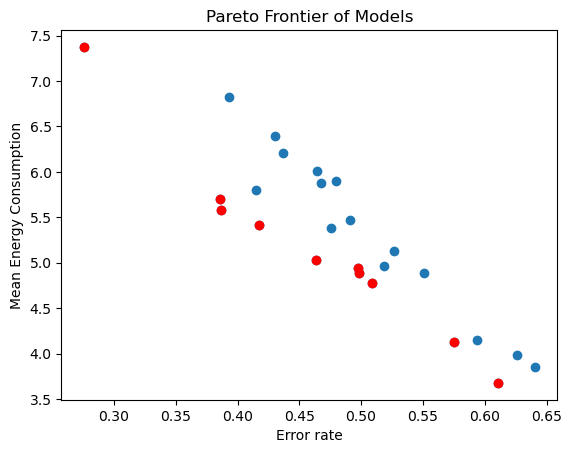

In [22]:
plt.scatter(solutions[:,0],solutions[:,1])
plt.scatter(pareto[:,0],pareto[:,1],color='red')
plt.title("Pareto Frontier of Models")
plt.xlabel("Error rate")
plt.ylabel("Mean Energy Consumption")
plt.show()

In [23]:
pareto_models = []
models = []
for error_rate, mean_energy_cost in pareto:
    model = Model(name,error_rate,mean_energy_cost)
    pareto_models.append(model)

for error_rate, mean_energy_cost in solutions:
    model = Model(name,error_rate,mean_energy_cost)
    models.append(model)
    

In [24]:
n_pareto_models = len(pareto_models)
model_idx = int(n_pareto_models*0.5)
single_tradeoff_model = pareto_models[model_idx]
print(single_tradeoff_model.error_rate,single_tradeoff_model.mean_energy_cost)

0.497644870548524 4.93608184250786


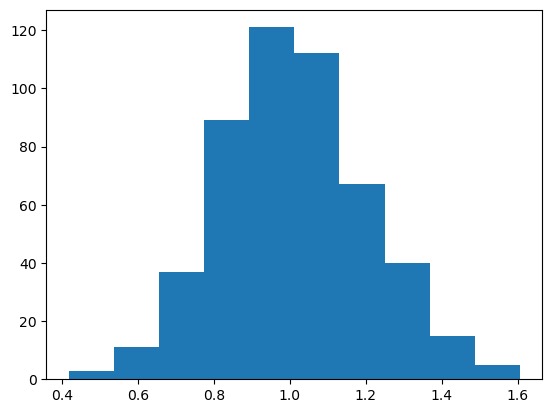

In [25]:
tasks = []
for t in range(500):
    difficulty = np.random.normal(loc=1, scale=0.2)
    #difficulty = 1.0
    #task = Task(difficulty)
    tasks.append(difficulty)
plt.hist(tasks)
plt.show()


In [26]:
# simulation - heuristics battery
# task difficulty estimation?
import math

def energy_aware_model_selection(battery_level, models):
    model_idx = math.floor(len(models)*battery_level)
    model_idx = clip(model_idx,0,len(models)-1)
    return models[model_idx]


def simulation_round(task_list, method, models, full_battery):    
    tasks_done = 0
    hits = 0
    current_battery = full_battery
    for task in task_list:
        if method == 'energy_aware':
            battery_level = current_battery/full_battery
            model = energy_aware_model_selection(battery_level, models)
        if method == 'baseline':
            model = single_tradeoff_model
        
        result, energy_cost = model.inference(task, energy_var = 0.0)
        current_battery -= energy_cost
        tasks_done += 1
        hits += int(result)

        if current_battery <= 0:
            break

    hit_rate = hits/tasks_done
    return hit_rate, tasks_done, hits 

In [27]:
# baseline
results_baseline = []
for i in range(1000):
    hit_rate, tasks_done, hits = simulation_round(tasks, 'baseline', models, 500)
    results_baseline.append([hit_rate, tasks_done, hits])
results_baseline = np.array(results_baseline)

In [28]:
# energy aware
results_energy_aware = []
for i in range(1000):
    hit_rate, tasks_done, hits = simulation_round(tasks, 'energy_aware', models, 500)
    results_energy_aware.append([hit_rate, tasks_done,hits])
results_energy_aware = np.array(results_energy_aware)

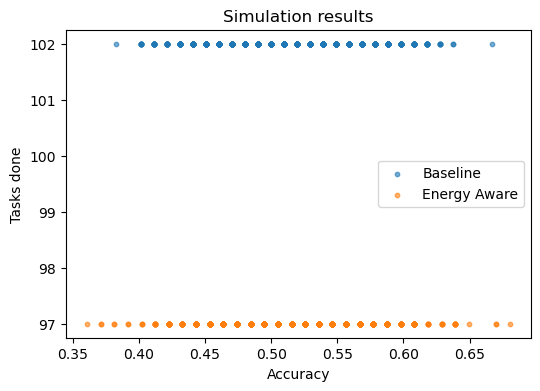

In [29]:
x1 = results_baseline[:, 0]
y1 = results_baseline[:, 1]
z1 = results_baseline[:, 2]
x2 = results_energy_aware[:, 0]
y2 = results_energy_aware[:, 1]
z2 = results_energy_aware[:, 2]

plt.figure(figsize=(6, 4))
plt.scatter(x1, y1, s=10, alpha=0.6, label="Baseline")
plt.scatter(x2, y2, s=10, alpha=0.6, label="Energy Aware")
plt.legend()
plt.xlabel("Accuracy")
plt.ylabel("Tasks done")
plt.title("Simulation results")
plt.show()

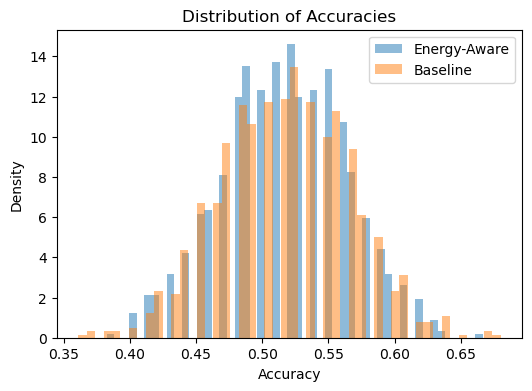

In [30]:
plt.figure(figsize=(6, 4))
plt.hist(x1, bins=50, alpha=0.5, density=True, label="Energy-Aware")
plt.hist(x2, bins=50, alpha=0.5, density=True, label="Baseline")
plt.xlabel("Accuracy")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of Accuracies")
plt.show()

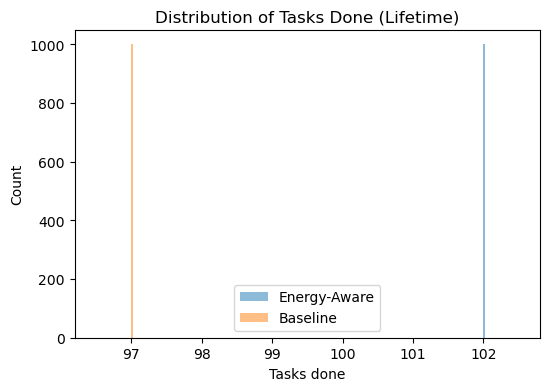

In [31]:
plt.figure(figsize=(6, 4))
plt.hist(y1, bins=50, alpha=0.5, label="Energy-Aware")
plt.hist(y2, bins=50, alpha=0.5, label="Baseline")
plt.xlabel("Tasks done")
plt.ylabel("Count")
plt.legend()
plt.title("Distribution of Tasks Done (Lifetime)")
plt.show()

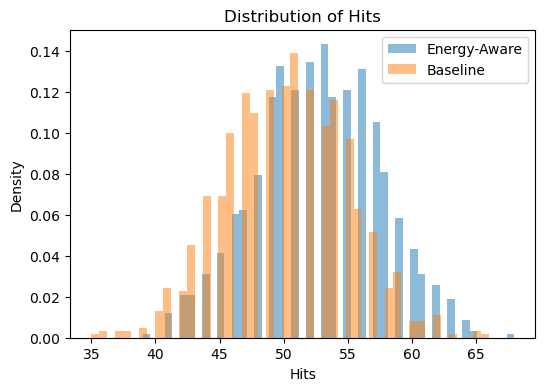

Mean hit difference:2.44


In [32]:

plt.figure(figsize=(6, 4))
plt.hist(z1, bins=50, alpha=0.5, density=True, label="Energy-Aware")
plt.hist(z2, bins=50, alpha=0.5, density=True, label="Baseline")
plt.xlabel("Hits")
plt.ylabel("Density")
plt.legend()
plt.title("Distribution of Hits")
plt.show()
print(f"Mean hit difference:{z1.mean()-z2.mean():.2f}",)